In [ ]:
import os
import sys
import json
import shap
import torch
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from scripts.models.nn.classes.factory import build_model
from scripts.models.nn.classes.dataset import load_split
warnings.filterwarnings('ignore')
sys.path.insert(0,os.path.abspath('..'))
pplt.rc.update({'figure.dpi':100,'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FEATSDIR   = CONFIGS['filepaths']['features']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
NNCONFIG   = MODELS['nn']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
FIELDVARS  = CONFIGS['variables']['field'][-3:]
LOCALVARS  = CONFIGS['variables']['local']
SPLIT      = 'valid'
BASENAME   = 'baseline_rh_thetae_thetaestar_lf_lhf_shf'
KERNNAME   = 'nonparametric_rh_thetae_thetaestar_lf_lhf_shf'
VARLABELS  = {
    'rh':'RH',
    'thetae':'$\\mathit{\\theta_{e}}$',
    'thetaestar':'$\\mathit{\\theta_{e}}^*$',
    'lhf':'Latent Heat Flux',
    'shf':'Sensible Heat Flux',
    'lf':'Land Fraction'}
LANDCOLOR  = 'jungle green'
OCEANCOLOR = 'steelblue'

In [4]:
evalds    = xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf')
ps        = evalds.ps.load()
landmask  = evalds.lf.load()>0.5

results = {}
for name,_ in NNCONFIG['runs'].items():
    if name not in (BASENAME,KERNNAME):
        continue
    ytrue = evalds.tp.load()
    ypred = xr.open_dataset(os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc'),engine='h5netcdf').tp.load()
    if name == BASENAME:
        field = evalds[FIELDVARS].load()
    else:
        field = xr.open_dataset(os.path.join(FEATSDIR,f'{name}_{SPLIT}_features.nc'),engine='h5netcdf')[FIELDVARS].load()
    local = evalds[LOCALVARS].load()
    align = xr.align(ytrue,ypred,field,local,join='inner')
    ytrue,ypred,field,local = align
    entry = {
        'ytrue':ytrue,
        'ypred':ypred,
        'field':field,
        'local':local}
    if name==KERNNAME:
        entry['weights'] = xr.open_dataset(os.path.join(WEIGHTSDIR,f'{name}_{SPLIT}_weights.nc')).load()
    results[name] = entry

print(f'Loaded {len(results)} models!')

Loaded 2 models!


In [5]:
def get_r2(ytrue,ypred,dims=None):
    dims = list(ytrue.dims) if dims is None else dims
    ssr  = ((ytrue-ypred)**2).sum(dim=dims,skipna=True)
    sst  = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return 1-ssr/sst

def bin_land_ocean(x,y,landmask,nbins=50):
    finite = np.isfinite(x)
    binedges   = np.quantile(x[finite],np.linspace(0,1,nbins+1))
    bincenters = 0.5*(binedges[:-1]+binedges[1:])
    landmean,landstd,oceanmean,oceanstd = [],[],[],[]
    for i in range(nbins):
        inrange = (x>=binedges[i])&(x<=binedges[i+1])
        yland  = y[inrange&landmask]
        yocean = y[inrange&~landmask]
        yland  = yland[np.isfinite(yland)]
        yocean = yocean[np.isfinite(yocean)]
        landmean.append(yland.mean() if len(yland) else np.nan)
        landstd.append(yland.std() if len(yland) else np.nan)
        oceanmean.append(yocean.mean() if len(yocean) else np.nan)
        oceanstd.append(yocean.std() if len(yocean) else np.nan)
    return bincenters,np.array(landmean),np.array(landstd),np.array(oceanmean),np.array(oceanstd)

In [6]:
def plot_r2_maps(results):
    base = results[BASENAME]
    kern = results[KERNNAME]
    ytrueb,ypredb = base['ytrue'],base['ypred']
    ytruek,ypredk = kern['ytrue'],kern['ypred']
    r2b  = get_r2(ytrueb,ypredb,dims=['time']).mean('seed').squeeze()
    r2k  = get_r2(ytruek,ypredk,dims=['time']).mean('seed').squeeze()
    diff = r2k-r2b
    fig,axs = pplt.subplots(nrows=1,ncols=3,refwidth=2,proj='cyl',share=False)
    axs.format(grid=False,coast=True,latlim=LATRANGE,lonlim=LONRANGE,
               collabels=['Baseline','Kernel','Kernel $-$ Baseline'])
    axs[0].pcolormesh(r2b.lon,r2b.lat,r2b,cmap='Blues',vmin=0,vmax=0.8,levels=17,extend='max')
    im1 = axs[1].pcolormesh(r2k.lon,r2k.lat,r2k,cmap='Blues',vmin=0,vmax=0.8,levels=17,extend='max')
    im2 = axs[2].pcolormesh(diff.lon,diff.lat,diff,cmap='ColdHot_r',vmin=-0.2,vmax=0.2,levels=9,extend='both')
    fig.colorbar(im1,loc='b',cols=(1,2),label='R$^2$',ticks=0.1)
    fig.colorbar(im2,loc='b',cols=3,label='$\Delta$R$^2$',ticks=0.1)
    pplt.show()
    
def plot_skill_diff_by_predictor(results,landmask,varnames=FIELDVARS+LOCALVARS,nbins=50):
    base = results[BASENAME]
    kern = results[KERNNAME]
    r2b  = get_r2(base['ytrue'],base['ypred'],dims=['time']).mean('seed').squeeze()
    r2k  = get_r2(kern['ytrue'],kern['ypred'],dims=['time']).mean('seed').squeeze()
    diff = r2k-r2b
    fig,axs = pplt.subplots(nrows=2,ncols=len(varnames)//2,refwidth=2,sharex=False,sharey=True)
    axs.format(suptitle='Dependence of Model Skill Improvement on Predictor Value',grid=True,
               ylabel='$\Delta R^2$ (Kernel $-$ Baseline)',ylim=(-0.75,0.25),yticks=0.25)
    for ax,varname in zip(axs,varnames):
        x = base['field'][varname] if varname in FIELDVARS else base['local'][varname]
        xmean = x.mean(dim=[d for d in x.dims if d not in ('lat','lon')])
        bincenters,landmean,landstd,oceanmean,oceanstd = bin_land_ocean(
            xmean.values.ravel(),diff.values.ravel(),landmask.values.ravel(),nbins=nbins)
        ax.fill_between(bincenters,landmean-landstd,landmean+landstd,color=LANDCOLOR,alpha=0.15)
        ax.fill_between(bincenters,oceanmean-oceanstd,oceanmean+oceanstd,color=OCEANCOLOR,alpha=0.15)
        ax.plot(bincenters,landmean,color=LANDCOLOR,linewidth=1.5,label='Land')
        ax.plot(bincenters,oceanmean,color=OCEANCOLOR,linewidth=1.5,label='Ocean')
        ax.axhline(0,color='k',linewidth=0.8,linestyle='--')
        ax.format(xlabel=VARLABELS[varname])
    axs[0].legend(loc='lr',ncols=1)
    pplt.show()

def plot_error_diff_by_ps(results,ps,landmask,nbins=50):
    base = results[BASENAME]
    kern = results[KERNNAME]
    residb = (base['ytrue']-base['ypred']).mean(['time','seed']).squeeze()
    residk = (kern['ytrue']-kern['ypred']).mean(['time','seed']).squeeze()
    diff   = residk-residb
    psmean = ps.mean('time')
    bincenters,landmean,landstd,oceanmean,oceanstd = bin_land_ocean(
        psmean.values.ravel(),diff.values.ravel(),landmask.values.ravel(),nbins=nbins)
    fig,ax = pplt.subplots(nrows=1,ncols=1,refheight=2,refwidth=6)
    ax.format(suptitle='Dependence of Model Error Difference on Surface Pressure',grid=True,
              xlabel='Surface Pressure (hPa)',ylabel='Difference in Mean Prediction\nError (Kernel $-$ Baseline)')
    ax.fill_between(bincenters,landmean-landstd,landmean+landstd,color=LANDCOLOR,alpha=0.15)
    ax.fill_between(bincenters,oceanmean-oceanstd,oceanmean+oceanstd,color=OCEANCOLOR,alpha=0.15)
    ax.plot(bincenters,landmean,color=LANDCOLOR,linewidth=1.5,label='Land')
    ax.plot(bincenters,oceanmean,color=OCEANCOLOR,linewidth=1.5,label='Ocean')
    ax.axhline(0,color='k',linewidth=0.8,ls='--')
    ax.legend(loc='ur',ncols=1)
    pplt.show()

def plot_predictor_variance(results,landmask):
    base = results[BASENAME]
    kern = results[KERNNAME]
    fig,axs = pplt.subplots(nrows=2,ncols=len(FIELDVARS),refwidth=1.8,sharex=False,sharey=1)
    axs.format(suptitle='Temporal Variability of Raw vs. Kernel-Integrated Field Predictors',grid=True,
               ylabel='Density',rowlabels=['Raw','Kernel-Integrated'])
    for col,varname in enumerate(FIELDVARS):
        isfield = varname in FIELDVARS
        for row,(label,src) in enumerate([('raw',base),('kern',kern)]):
            ax = axs[row,col]
            if row==1:
                ax.format(xlabel=f'Temporal $\sigma$ of {VARLABELS[varname]}')
            x = src['field'][varname] if isfield else src['local'][varname]
            if 'seed' in x.dims:
                x = x.mean('seed')
            varstd = x.std(dim=[d for d in x.dims if d not in ('lat','lon')])
            bins   = np.linspace(np.nanmin(varstd.values),np.nanmax(varstd.values),50)
            landvalues  = varstd.where(landmask).values.ravel()
            oceanvalues = varstd.where(~landmask).values.ravel()
            landvalues  = landvalues[np.isfinite(landvalues)]
            oceanvalues = oceanvalues[np.isfinite(oceanvalues)]
            ax.hist(landvalues,bins=bins,color=LANDCOLOR,alpha=0.5,density=True,label='Land')
            ax.hist(oceanvalues,bins=bins,color=OCEANCOLOR,alpha=0.5,density=True,label='Ocean')
    axs[0,0].legend(loc='ur',ncols=1)
    pplt.show()

def plot_weights(results):
    kern    = results[KERNNAME]
    weights = kern['weights']
    levels  = weights['lev'].values
    fig,axs = pplt.subplots(nrows=1,ncols=len(FIELDVARS),refheight=2,refwidth=1,share=True)
    axs.format(suptitle='Nonparametric Kernel Weights',grid=True,
               xlabel='Normalized Kernel Weight',ylabel='Pressure (hPa)')
    for ax,varname in zip(axs,FIELDVARS):
        wmean = weights['k1'].sel(field=varname).mean('seed').values
        wstd  = weights['k1'].sel(field=varname).std('seed').values
        ax.plot(wmean,levels,color='k',linewidth=1.5)
        ax.fill_betweenx(levels,wmean-wstd,wmean+wstd,color='k',alpha=0.2)
        ax.axvline(0,color='k',linewidth=0.8,linestyle='--')
        ax.format(title=VARLABELS[varname],xlim=(-0.005,0.008),yreverse=True)
    pplt.show()

def plot_tp_relationships(results,landmask,nbins=50):
    base = results[BASENAME]
    kern = results[KERNNAME]
    ytrue,ypredb,ypredk = xr.align(base['ytrue'],
        base['ypred'].mean('seed') if 'seed' in base['ypred'].dims else base['ypred'],
        kern['ypred'].mean('seed') if 'seed' in kern['ypred'].dims else kern['ypred'],
        join='inner')
    ytrue,ypredb,ypredk = ytrue.squeeze(),ypredb.squeeze(),ypredk.squeeze()
    predictors = FIELDVARS+[v for v in LOCALVARS if v!='lf']
    predictordata = {}
    for varname in predictors:
        vardata   = base['field'][varname] if varname in FIELDVARS else base['local'][varname]
        extradims = [d for d in vardata.dims if d not in ('time','lat','lon')]
        if extradims:
            vardata = vardata.mean(dim=extradims)
        predictordata[varname],_ = xr.align(vardata,ytrue,join='inner')
    ds = xr.Dataset({
        'ytrue':ytrue,
        'ypredb':ypredb,
        'ypredk':ypredk,
        'landmask':landmask.reindex_like(ytrue,method=None).broadcast_like(ytrue)})
    for varname in predictors:
        ds[f'x_{varname}'] = predictordata[varname]
    stacked      = ds.stack(sample=ytrue.dims).dropna('sample',subset=['ytrue'])
    ytruevalues  = stacked['ytrue'].values
    ypredbvalues = stacked['ypredb'].values
    ypredkvalues = stacked['ypredk'].values
    landmaskflat = stacked['landmask'].values.astype(bool)
    fig,axs = pplt.subplots(nrows=2,ncols=len(predictors),refwidth=2,sharex=False,sharey='labels')
    axs.format(suptitle='Conditional Average Precipitation by Predictor',grid=True,rowlabels=['Land','Ocean'])
    for col,varname in enumerate(predictors):
        xvalues    = stacked[f'x_{varname}'].values
        finite     = np.isfinite(xvalues)&np.isfinite(ytruevalues)
        binedges   = np.quantile(xvalues[finite],np.linspace(0,1,nbins+1))
        bincenters = 0.5*(binedges[:-1]+binedges[1:])
        for row,(surftype,surfmask) in enumerate([('Land',landmaskflat),('Ocean',~landmaskflat)]):
            ax = axs[row,col]
            ytruemeans,ypredbmeans,ypredkmeans = [],[],[]
            for i in range(nbins):
                selection = finite&surfmask&(xvalues>=binedges[i])&(xvalues<=binedges[i+1])
                if selection.sum()>10:
                    ytruemeans.append(ytruevalues[selection].mean())
                    ypredbmeans.append(ypredbvalues[selection].mean())
                    ypredkmeans.append(ypredkvalues[selection].mean())
                else:
                    ytruemeans.append(np.nan)
                    ypredbmeans.append(np.nan)
                    ypredkmeans.append(np.nan)
            color = LANDCOLOR if surftype=='Land' else OCEANCOLOR
            ax.plot(bincenters,ytruemeans,color='k',label='Truth')
            ax.plot(bincenters,ypredbmeans,color=color,label='Baseline')
            ax.plot(bincenters,ypredkmeans,linestyle='--',color=color,label='Kernel')
            if col==0:
                ax.format(ylabel='Total Precipitaiton (mm)')
                ax.legend(loc='ul',ncols=1)
            if row==1:
                ax.format(xlabel=VARLABELS.get(varname,varname))         
    pplt.show()

In [ ]:
def plot_lost_weight_vs_error(results,ps,landmask,nbins=50):
    kern    = results[KERNNAME]
    base    = results[BASENAME]
    weights = kern['weights']
    evalds  = xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf')
    dlev    = evalds['dlev'].load()
    smask   = evalds['surfmask'].load()
    kw      = weights['k1'].mean('seed')
    lostweight = {}
    for varname in FIELDVARS:
        kwvar    = kw.sel(field=varname)
        weighted = (kwvar*dlev*smask).sum('lev')
        lostweight[varname] = 1.0-weighted
    residb = (base['ytrue']-base['ypred']).mean(['time','seed']).squeeze()
    residk = (kern['ytrue']-kern['ypred']).mean(['time','seed']).squeeze()
    diff   = residk-residb
    fig,axs = pplt.subplots(nrows=1,ncols=len(FIELDVARS),refheight=2.5,refwidth=2.5,sharex=False,sharey=True)
    axs.format(suptitle='Kernel Integration Deficit vs. Error Difference',grid=True,
               ylabel='Difference in Mean Prediction\nError (Kernel $-$ Baseline)')
    for ax,varname in zip(axs,FIELDVARS):
        lw = lostweight[varname]
        lw,diffal = xr.align(lw,diff,join='inner')
        lw,lmal   = xr.align(lw,landmask,join='inner')
        bincenters,landmean,landstd,oceanmean,oceanstd = bin_land_ocean(
            lw.values.ravel(),diffal.values.ravel(),lmal.values.ravel(),nbins=nbins)
        ax.fill_between(bincenters,landmean-landstd,landmean+landstd,color=LANDCOLOR,alpha=0.15)
        ax.fill_between(bincenters,oceanmean-oceanstd,oceanmean+oceanstd,color=OCEANCOLOR,alpha=0.15)
        ax.plot(bincenters,landmean,color=LANDCOLOR,linewidth=1.5,label='Land')
        ax.plot(bincenters,oceanmean,color=OCEANCOLOR,linewidth=1.5,label='Ocean')
        ax.axhline(0,color='k',linewidth=0.8,linestyle='--')
        ax.format(xlabel=f'Lost Weight (1 $-$ $\\Sigma k \\cdot \\Delta p \\cdot m$)\nfor {VARLABELS[varname]}')
    axs[0].legend(loc='lr',ncols=1)
    pplt.show()

def plot_error_diff_by_ps_and_predictor(results,ps,landmask,varnames=FIELDVARS,nps=5,nbins=30):
    base = results[BASENAME]
    kern = results[KERNNAME]
    residb = (base['ytrue']-base['ypred']).mean(['time','seed']).squeeze()
    residk = (kern['ytrue']-kern['ypred']).mean(['time','seed']).squeeze()
    diff   = residk-residb
    psmean = ps.mean('time')
    psmean,diffal = xr.align(psmean,diff,join='inner')
    psmean,lmal   = xr.align(psmean,landmask,join='inner')
    psflat   = psmean.values.ravel()
    diffflat = diffal.values.ravel()
    landflat = lmal.values.ravel()
    finite   = np.isfinite(psflat)
    psedges  = np.quantile(psflat[finite],np.linspace(0,1,nps+1))
    pslabels = [f'{psedges[i]:.0f}–{psedges[i+1]:.0f} hPa' for i in range(nps)]
    fig,axs = pplt.subplots(nrows=2,ncols=len(varnames),refheight=2,refwidth=2.5,sharex=False,sharey=True)
    axs.format(suptitle='Error Difference Stratified by $p_s$ and Predictor Value',grid=True,
               ylabel='Difference in Mean Prediction\nError (Kernel $-$ Baseline)',
               rowlabels=['Land','Ocean'])
    cmap = pplt.Colormap('Spectral',N=nps)
    for col,varname in enumerate(varnames):
        x = base['field'][varname] if varname in FIELDVARS else base['local'][varname]
        xmean = x.mean(dim=[d for d in x.dims if d not in ('lat','lon')])
        xmean,_ = xr.align(xmean,diffal,join='inner')
        xflat = xmean.values.ravel()
        for row,(surftype,surfsel) in enumerate([('Land',landflat),('Ocean',~landflat)]):
            ax = axs[row,col]
            for k in range(nps):
                psbin = (psflat>=psedges[k])&(psflat<=psedges[k+1])&surfsel&finite
                xsub  = xflat[psbin]
                dsub  = diffflat[psbin]
                finitesub  = np.isfinite(xsub)&np.isfinite(dsub)
                xsub,dsub  = xsub[finitesub],dsub[finitesub]
                if len(xsub)<20:
                    continue
                bedges   = np.quantile(xsub,np.linspace(0,1,nbins+1))
                bcenters = 0.5*(bedges[:-1]+bedges[1:])
                means = []
                for i in range(nbins):
                    sel = (xsub>=bedges[i])&(xsub<=bedges[i+1])
                    means.append(dsub[sel].mean() if sel.sum()>5 else np.nan)
                ax.plot(bcenters,means,color=cmap(k),linewidth=1.2,label=pslabels[k] if row==0 and col==0 else None)
            ax.axhline(0,color='k',linewidth=0.8,linestyle='--')
            if row==1:
                ax.format(xlabel=VARLABELS[varname])
    axs[0,0].legend(loc='lr',ncols=1,title='$p_s$ bin',fontsize=6)
    pplt.show()

def plot_renormalized_counterfactual(results,landmask,nbins=50):
    kern   = results[KERNNAME]
    base   = results[BASENAME]
    evalds = xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf')
    dlev   = evalds['dlev'].load()
    smask  = evalds['surfmask'].load()
    kw     = kern['weights']['k1'].mean('seed')
    rawfields = {}
    for varname in FIELDVARS:
        rawfields[varname] = evalds[varname].load()
    renorm_features = {}
    original_features = {}
    for varname in FIELDVARS:
        kwvar  = kw.sel(field=varname)
        fld    = rawfields[varname]
        w_dp   = kwvar*dlev
        w_dp_m = w_dp*smask
        original_features[varname] = (fld*w_dp_m).sum('lev')
        wsum = w_dp_m.sum('lev')
        w_renorm = xr.where(wsum>1e-8,w_dp_m/wsum,0.0)
        renorm_features[varname] = (fld*w_renorm).sum('lev')
    field_orig,local,target,_,nlevs,_,_,_ = load_split(SPLIT,FIELDVARS,LOCALVARS,SPLITSDIR,targetvar='tp')
    modelk = build_model(KERNNAME,NNCONFIG['runs'][KERNNAME],nlevs)
    seeds  = NNCONFIG['seeds']
    ytrue  = kern['ytrue']
    ypred_renorm_list = []
    for seed in seeds:
        modelk.load_state_dict(torch.load(os.path.join(MODELSDIR,'nn',f'{KERNNAME}_{seed}.pth'),map_location='cpu',weights_only=True))
        modelk.eval()
        renorm_stack = xr.Dataset({v:renorm_features[v] for v in FIELDVARS})
        renorm_stack = renorm_stack.transpose('time','lat','lon')
        nlat,nlon = renorm_stack.sizes['lat'],renorm_stack.sizes['lon']
        ntime     = renorm_stack.sizes['time']
        feats_flat = np.stack([renorm_stack[v].values.reshape(-1) for v in FIELDVARS],axis=1)
        local_ds   = evalds[LOCALVARS].load()
        local_arrays = []
        for v in LOCALVARS:
            if 'time' in local_ds[v].dims:
                arr = local_ds[v].transpose('time','lat','lon').values.reshape(-1)
            else:
                arr = np.tile(local_ds[v].values,(ntime,1,1)).reshape(-1)
            local_arrays.append(arr)
        local_flat = np.stack(local_arrays,axis=1)
        valid = np.isfinite(feats_flat).all(axis=1)&np.isfinite(local_flat).all(axis=1)
        feats_valid = torch.from_numpy(feats_flat[valid].astype(np.float32))
        local_valid = torch.from_numpy(local_flat[valid].astype(np.float32))
        X = torch.cat([feats_valid,local_valid],dim=1)
        with torch.no_grad():
            zpred = modelk.model(X).numpy()
        pred_full = np.full(feats_flat.shape[0],np.nan,dtype=np.float32)
        pred_full[valid] = zpred
        pred_da = xr.DataArray(
            pred_full.reshape(ntime,nlat,nlon),
            dims=('time','lat','lon'),
            coords={'time':renorm_stack.time,'lat':renorm_stack.lat,'lon':renorm_stack.lon})
        ypred_renorm_list.append(pred_da)
    ypred_renorm = xr.concat(ypred_renorm_list,dim='seed').assign_coords(seed=seeds)
    ytrue_al,ypredk_al,ypredr_al,ypredb_al = xr.align(
        ytrue,
        kern['ypred'].mean('seed') if 'seed' in kern['ypred'].dims else kern['ypred'],
        ypred_renorm.mean('seed'),
        base['ypred'].mean('seed') if 'seed' in base['ypred'].dims else base['ypred'],
        join='inner')
    ytrue_al  = ytrue_al.squeeze()
    ypredk_al = ypredk_al.squeeze()
    ypredr_al = ypredr_al.squeeze()
    ypredb_al = ypredb_al.squeeze()
    predictors = FIELDVARS+[v for v in LOCALVARS if v!='lf']
    predictordata = {}
    for varname in predictors:
        vardata   = base['field'][varname] if varname in FIELDVARS else base['local'][varname]
        extradims = [d for d in vardata.dims if d not in ('time','lat','lon')]
        if extradims:
            vardata = vardata.mean(dim=extradims)
        predictordata[varname],_ = xr.align(vardata,ytrue_al,join='inner')
    ds = xr.Dataset({
        'ytrue':ytrue_al,
        'ypredb':ypredb_al,
        'ypredk':ypredk_al,
        'ypredr':ypredr_al,
        'landmask':landmask.reindex_like(ytrue_al,method=None).broadcast_like(ytrue_al)})
    for varname in predictors:
        ds[f'x_{varname}'] = predictordata[varname]
    stacked      = ds.stack(sample=ytrue_al.dims).dropna('sample',subset=['ytrue'])
    ytruevalues  = stacked['ytrue'].values
    ypredbvalues = stacked['ypredb'].values
    ypredkvalues = stacked['ypredk'].values
    ypredrvalues = stacked['ypredr'].values
    landmaskflat = stacked['landmask'].values.astype(bool)
    fig,axs = pplt.subplots(nrows=2,ncols=len(predictors),refwidth=2,sharex=False,sharey='labels')
    axs.format(suptitle='Renormalized Kernel Counterfactual: Conditional Average Precipitation',
               grid=True,rowlabels=['Land','Ocean'])
    for col,varname in enumerate(predictors):
        xvalues    = stacked[f'x_{varname}'].values
        finite     = np.isfinite(xvalues)&np.isfinite(ytruevalues)
        binedges   = np.quantile(xvalues[finite],np.linspace(0,1,nbins+1))
        bincenters = 0.5*(binedges[:-1]+binedges[1:])
        for row,(surftype,surfmask) in enumerate([('Land',landmaskflat),('Ocean',~landmaskflat)]):
            ax = axs[row,col]
            ytruemeans,ypredbmeans,ypredkmeans,ypredrmeans = [],[],[],[]
            for i in range(nbins):
                selection = finite&surfmask&(xvalues>=binedges[i])&(xvalues<=binedges[i+1])
                if selection.sum()>10:
                    ytruemeans.append(ytruevalues[selection].mean())
                    ypredbmeans.append(ypredbvalues[selection].mean())
                    ypredkmeans.append(ypredkvalues[selection].mean())
                    ypredrmeans.append(ypredrvalues[selection].mean())
                else:
                    ytruemeans.append(np.nan)
                    ypredbmeans.append(np.nan)
                    ypredkmeans.append(np.nan)
                    ypredrmeans.append(np.nan)
            color = LANDCOLOR if surftype=='Land' else OCEANCOLOR
            ax.plot(bincenters,ytruemeans,color='k',label='Truth')
            ax.plot(bincenters,ypredbmeans,color=color,label='Baseline')
            ax.plot(bincenters,ypredkmeans,linestyle='--',color=color,label='Kernel')
            ax.plot(bincenters,ypredrmeans,linestyle=':',linewidth=2,color='red',label='Kernel (renorm.)')
            if col==0:
                ax.format(ylabel='Total Precipitation (mm)')
                ax.legend(loc='ul',ncols=1)
            if row==1:
                ax.format(xlabel=VARLABELS.get(varname,varname))
    pplt.show()

In [ ]:
def compute_shap_error(split,nbackground=500,nexplained=200,ncoalition=250):
    field,local,ytrue,dlev,nlevs,_,_,_ = load_split(split,FIELDVARS,LOCALVARS,SPLITSDIR,targetvar='tp')
    nfieldvars = len(FIELDVARS)
    nlocalvars = len(LOCALVARS)
    X    = np.hstack([field.numpy().reshape(len(field),-1),local.numpy()])
    land = local[:,0].numpy()>0.5
    varslices = {}
    for i,var in enumerate(FIELDVARS):
        varslices[var] = slice(i*nlevs,(i+1)*nlevs)
    for j,var in enumerate(LOCALVARS):
        varslices[var] = slice(nfieldvars*nlevs+j,nfieldvars*nlevs+j+1)
    def error_decomposition(shapvalues,ytrue,ypred):
        sqerr = (ypred-ytrue)**2
        abssv = np.abs(shapvalues)
        total = abssv.sum(axis=1,keepdims=True)
        total = np.where(total==0,1,total)
        weights = abssv/total*sqerr[:,np.newaxis]
        return {v:weights[:,varslices[v]].sum(axis=1).mean() for v in varslices}
    def predict_function(model,haskernel):
        def predict(x):
            x = np.atleast_2d(x).astype(np.float32)
            n = x.shape[0]
            fieldtensor = torch.from_numpy(x[:,:nfieldvars*nlevs].reshape(n,nfieldvars,nlevs))
            localtensor = torch.from_numpy(x[:,nfieldvars*nlevs:])
            with torch.no_grad():
                out = model(fieldtensor,dlev,localtensor,mask=None) if haskernel else \
                      model(fieldtensor,localtensor,mask=torch.ones(n,nlevs))
            return np.atleast_1d(out.numpy())
        return predict
    modelb = build_model(BASENAME,NNCONFIG['runs'][BASENAME],nlevs)
    modelb.load_state_dict(torch.load(os.path.join(MODELSDIR,'nn',f'{BASENAME}_42.pth'),map_location='cpu',weights_only=True))
    modelb.eval()
    modelk = build_model(KERNNAME,NNCONFIG['runs'][KERNNAME],nlevs)
    modelk.load_state_dict(torch.load(os.path.join(MODELSDIR,'nn',f'{KERNNAME}_42.pth'),map_location='cpu',weights_only=True))
    modelk.eval()
    functionb = predict_function(modelb,False)
    functionk = predict_function(modelk,True)
    rng = np.random.default_rng(42)
    landidx  = np.where(land)[0]
    oceanidx = np.where(~land)[0]
    background  = X[rng.choice(len(X),nbackground,replace=False)]
    landsample  = rng.choice(landidx,min(nexplained,len(landidx)),replace=False)
    oceansample = rng.choice(oceanidx,min(nexplained,len(oceanidx)),replace=False)
    explainerb = shap.KernelExplainer(functionb,background)
    explainerk = shap.KernelExplainer(functionk,background)
    shapbland  = explainerb.shap_values(X[landsample],nsamples=ncoalition,silent=True)
    shapbocean = explainerb.shap_values(X[oceansample],nsamples=ncoalition,silent=True)
    shapkland  = explainerk.shap_values(X[landsample],nsamples=ncoalition,silent=True)
    shapkocean = explainerk.shap_values(X[oceansample],nsamples=ncoalition,silent=True)
    ytrueland   = ytrue[landsample].numpy().ravel()
    ytrueocean  = ytrue[oceansample].numpy().ravel()
    ypredbland  = functionb(X[landsample]).ravel()
    ypredbocean = functionb(X[oceansample]).ravel()
    ypredkland  = functionk(X[landsample]).ravel()
    ypredkocean = functionk(X[oceansample]).ravel()
    edbland  = error_decomposition(shapbland,ytrueland,ypredbland)
    edbocean = error_decomposition(shapbocean,ytrueocean,ypredbocean)
    edkland  = error_decomposition(shapkland,ytrueland,ypredkland)
    edkocean = error_decomposition(shapkocean,ytrueocean,ypredkocean)
    return edbland,edbocean,edkland,edkocean,list(varslices.keys())

def plot_shap_error(edbland,edbocean,edkland,edkocean,varnames):
    labels     = [VARLABELS.get(v,v) for v in varnames]
    xpos,width = np.arange(len(varnames)),0.18
    fig,axs    = pplt.subplots(nrows=1,ncols=2,refheight=2,refwidth=3,sharex=True,sharey=False)
    axs.format(suptitle='SHAP Error Decomposition',grid=True)
    for i,(model,edland,edocean) in enumerate([('Baseline',edbland,edbocean),('Kernel',edkland,edkocean)]):
        for j,(surface,ed,color) in enumerate([('Land',edland,LANDCOLOR),('Ocean',edocean,OCEANCOLOR)]):
            axs[0].bar(xpos+(i*2+j-1.5)*width,[ed[v] for v in varnames],
                       width=width,color=color,hatch='' if i==0 else '//',alpha=0.5+0.25*i,label=f'{model} {surface}')
    axs[0].format(title='Error Decomposition by Predictor',ylabel='MSE Contribution')
    axs[0].legend(loc='ur',ncols=1)
    diffland  = {v:edkland[v]-edbland[v] for v in varnames}
    diffocean = {v:edkocean[v]-edbocean[v] for v in varnames}
    axs[1].bar(xpos-0.15,[diffland[v]  for v in varnames],width=0.28,color=LANDCOLOR,label='Land')
    axs[1].bar(xpos+0.15,[diffocean[v] for v in varnames],width=0.28,color=OCEANCOLOR,label='Ocean')
    axs[1].axhline(0,color='k',linewidth=0.8,linestyle='--')
    axs[1].format(title='Change in Error Attribution',ylabel='$\Delta$ MSE Contribution\n(Kernel $-$ Baseline)')
    axs[1].legend(loc='lr',ncols=1)
    axs.format(xticks=xpos,xticklabels=labels,xrotation=30,xminorticks='none')
    pplt.show()

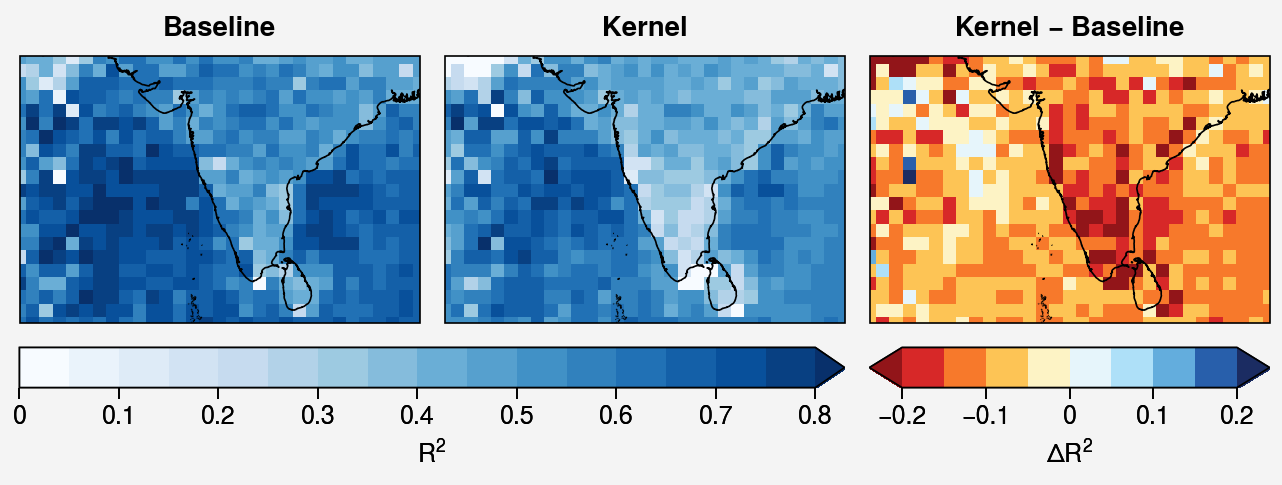

In [70]:
plot_r2_maps(results)

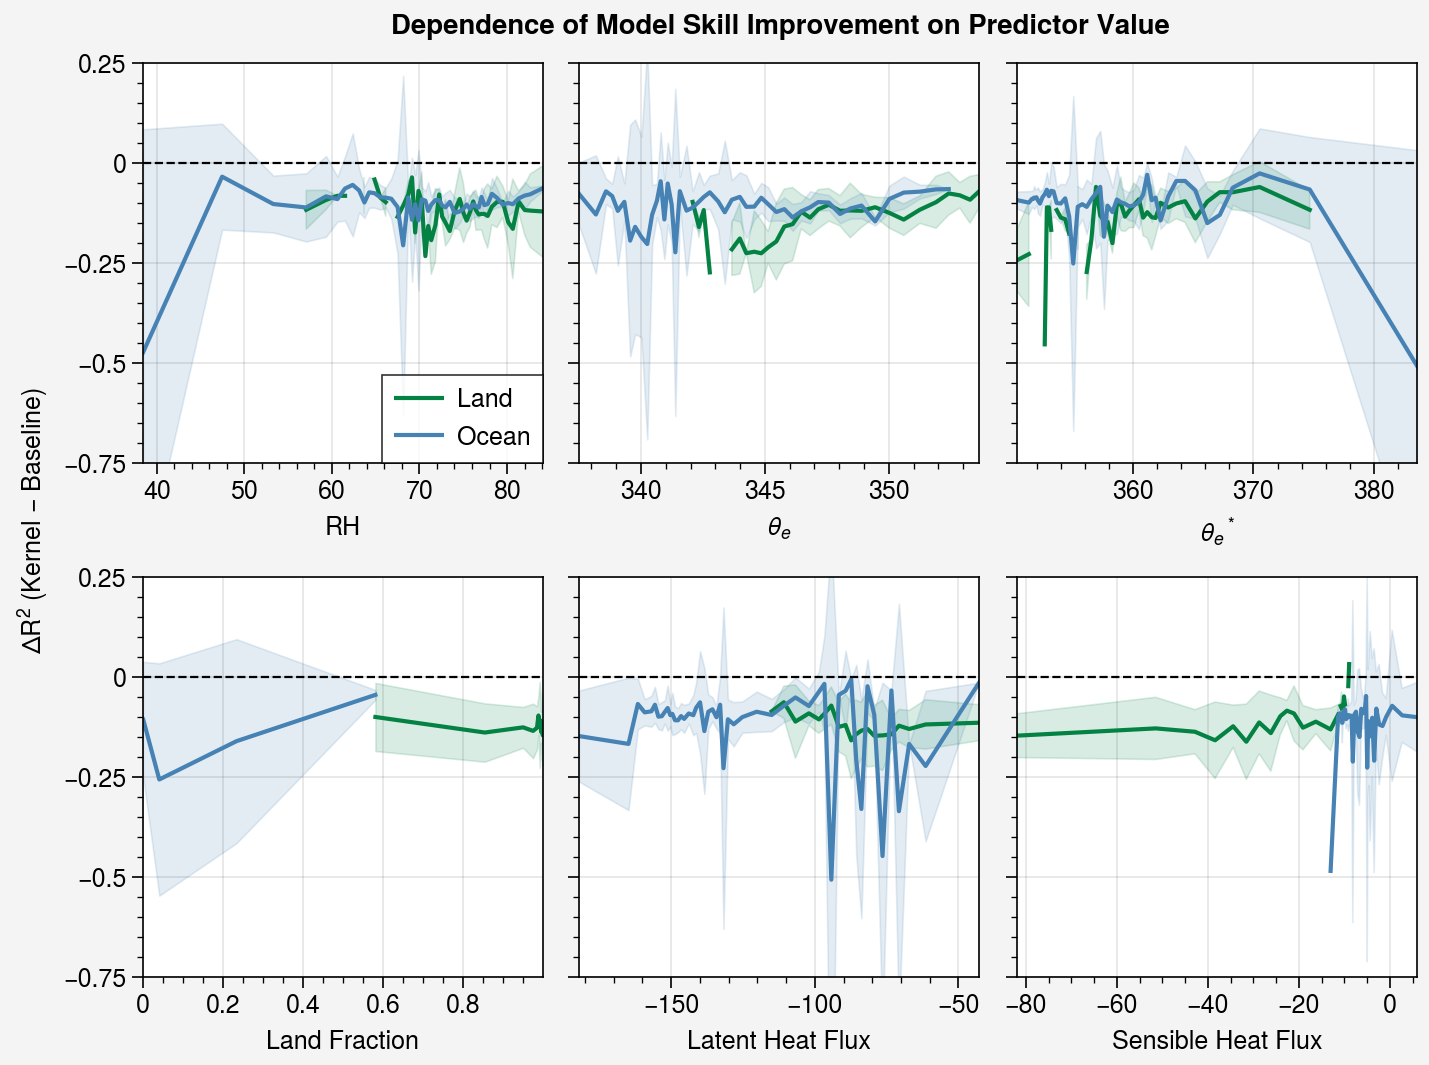

In [71]:
plot_skill_diff_by_predictor(results,landmask)

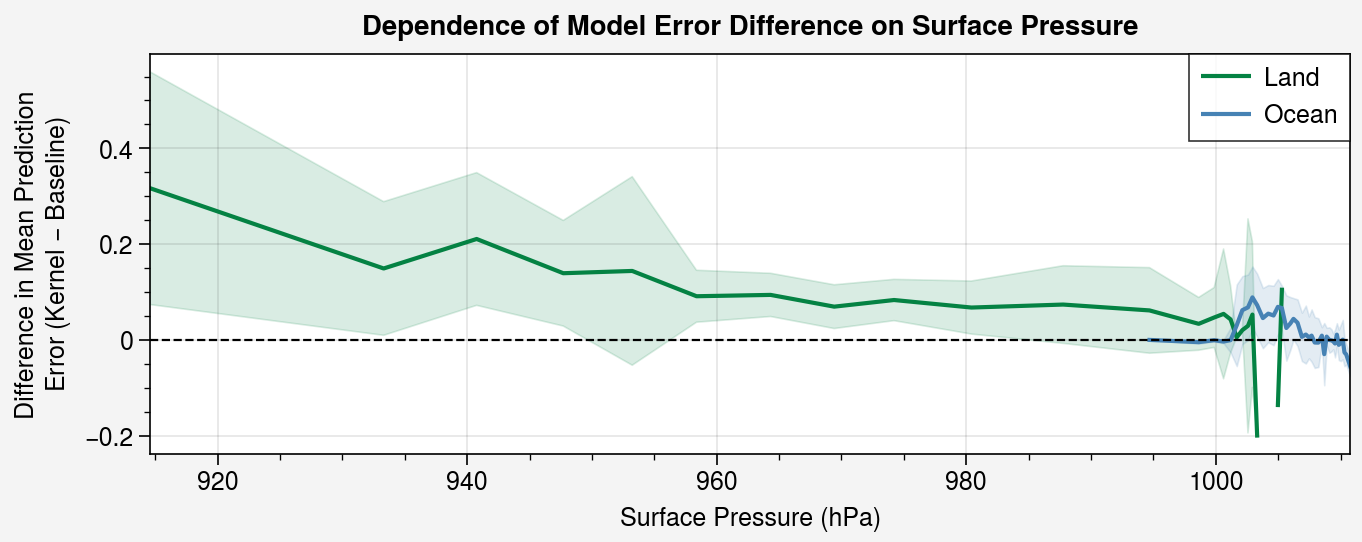

In [72]:
plot_error_diff_by_ps(results,ps,landmask)

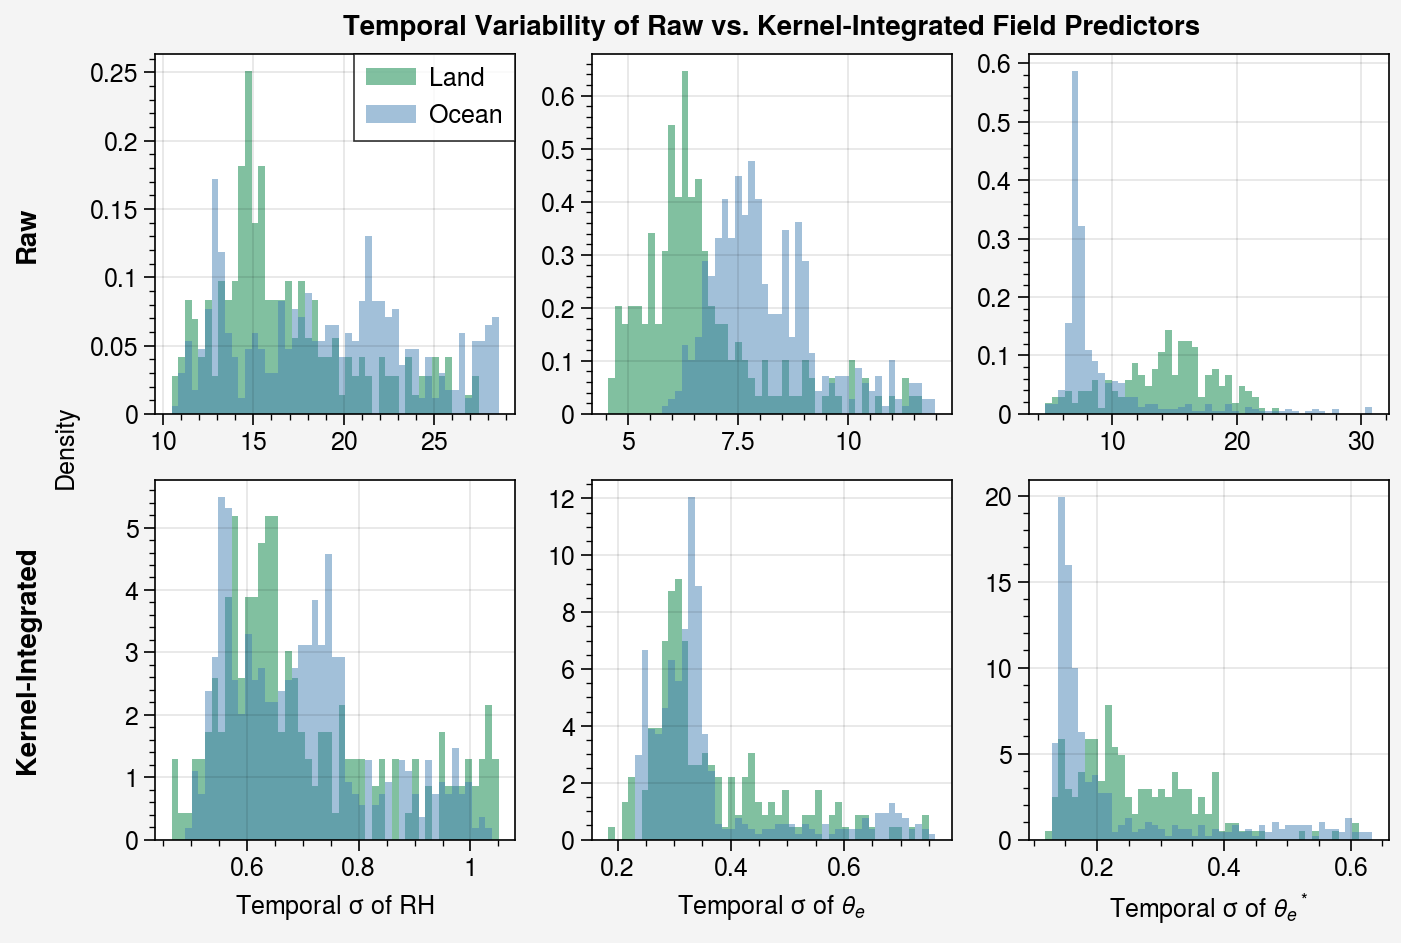

In [73]:
plot_predictor_variance(results,landmask)

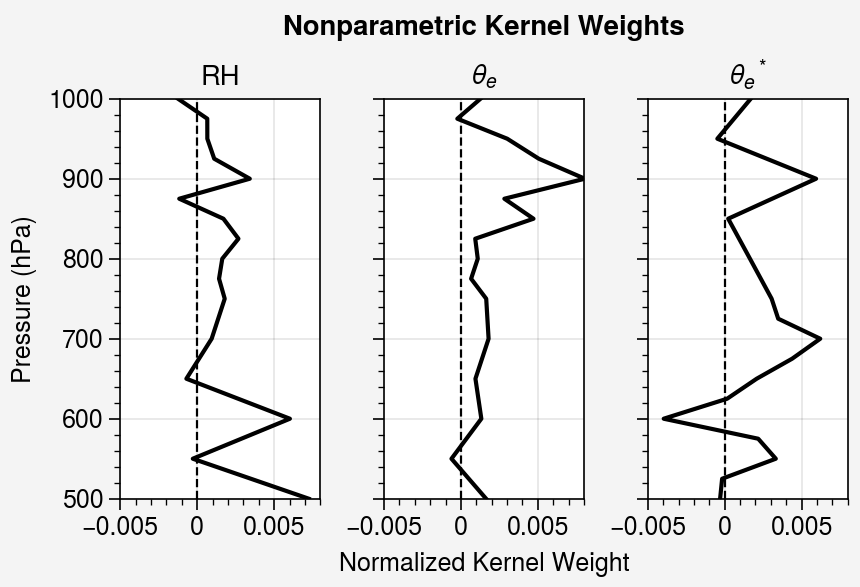

In [74]:
plot_weights(results)

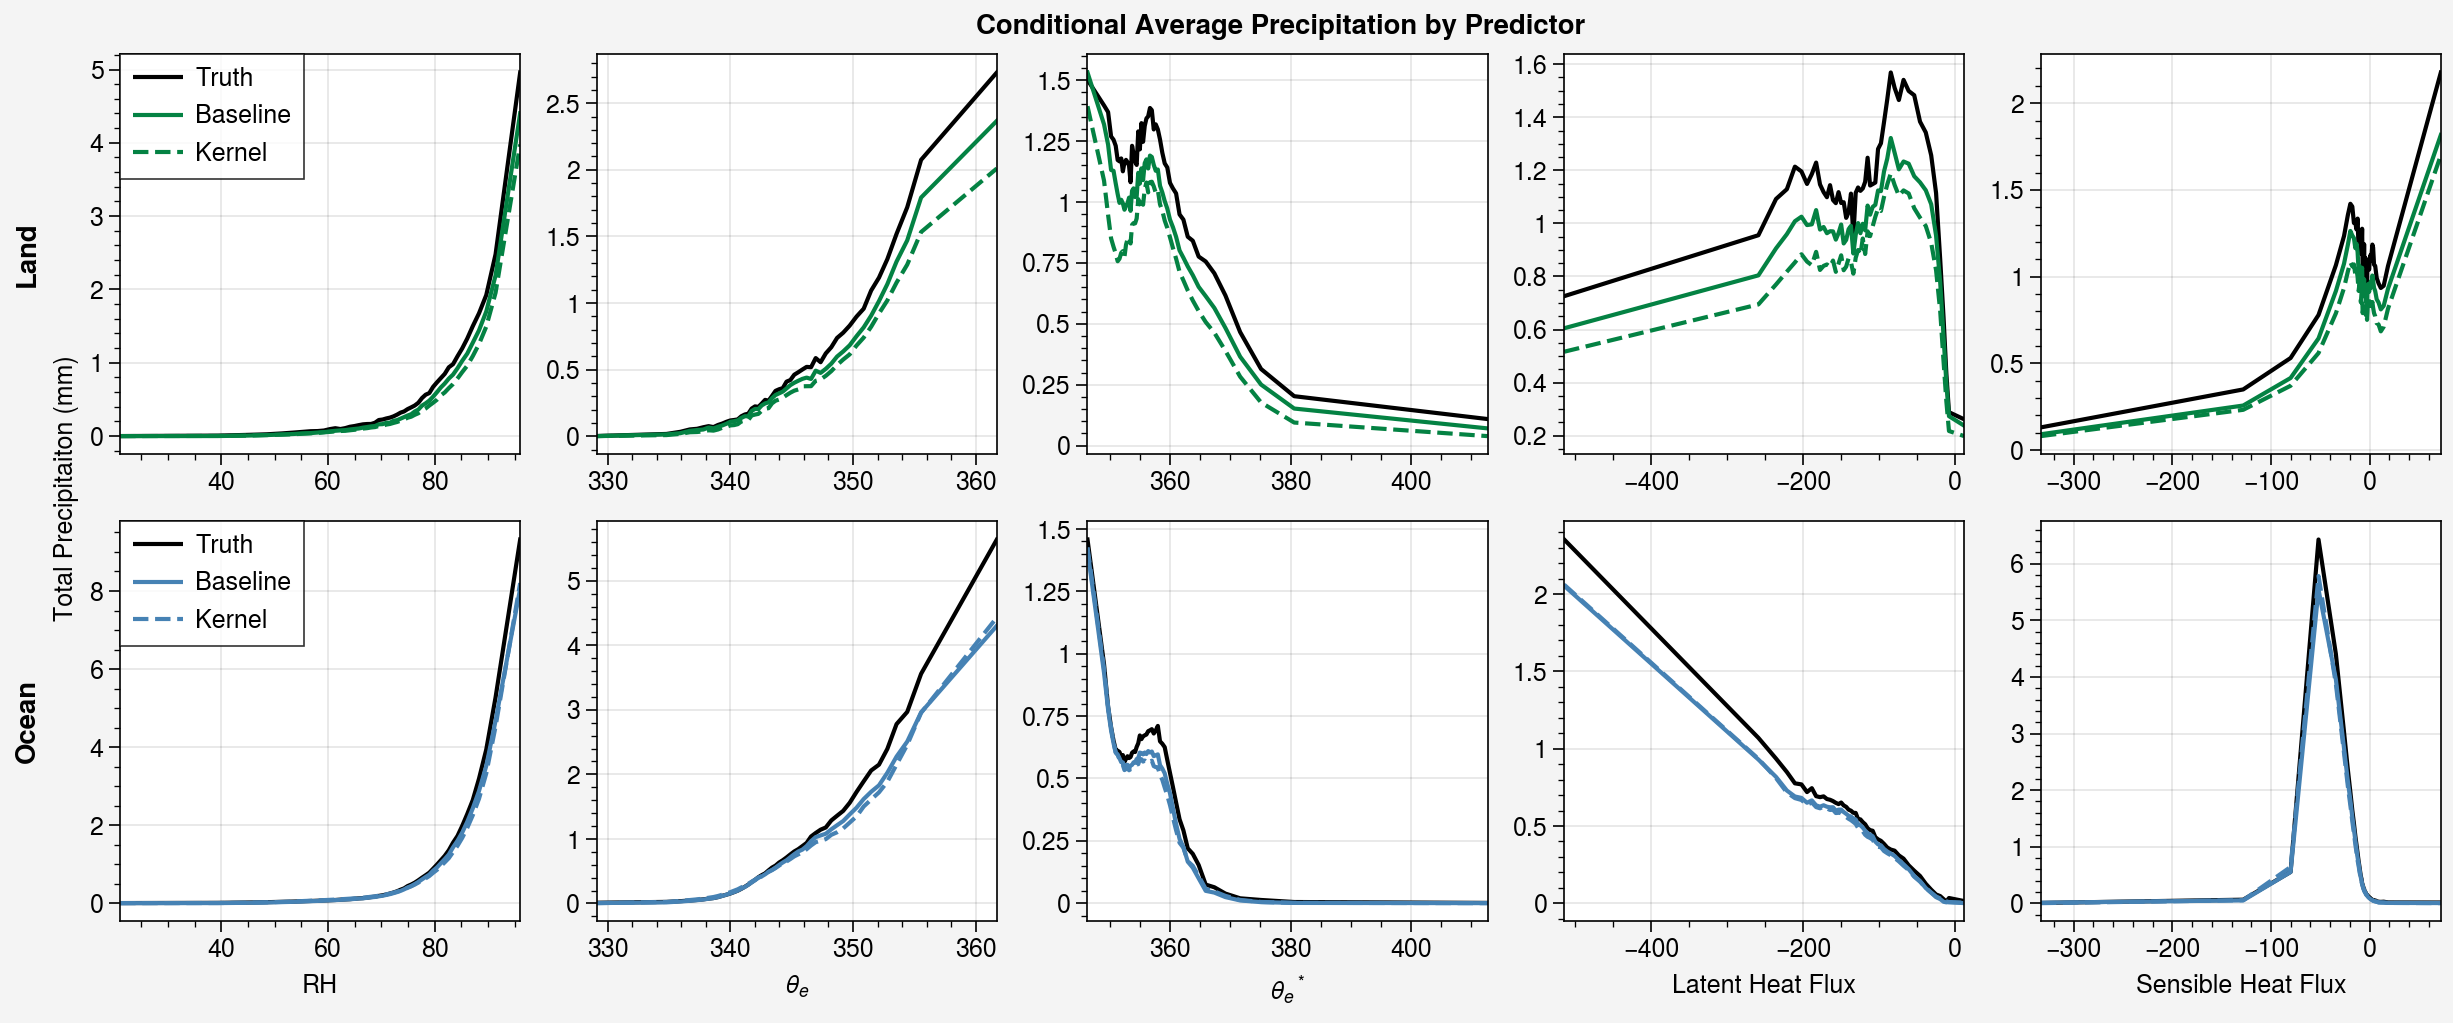

In [75]:
plot_tp_relationships(results,landmask)

In [ ]:
plot_lost_weight_vs_error(results,ps,landmask)

In [ ]:
plot_error_diff_by_ps_and_predictor(results,ps,landmask)

In [ ]:
plot_renormalized_counterfactual(results,landmask)

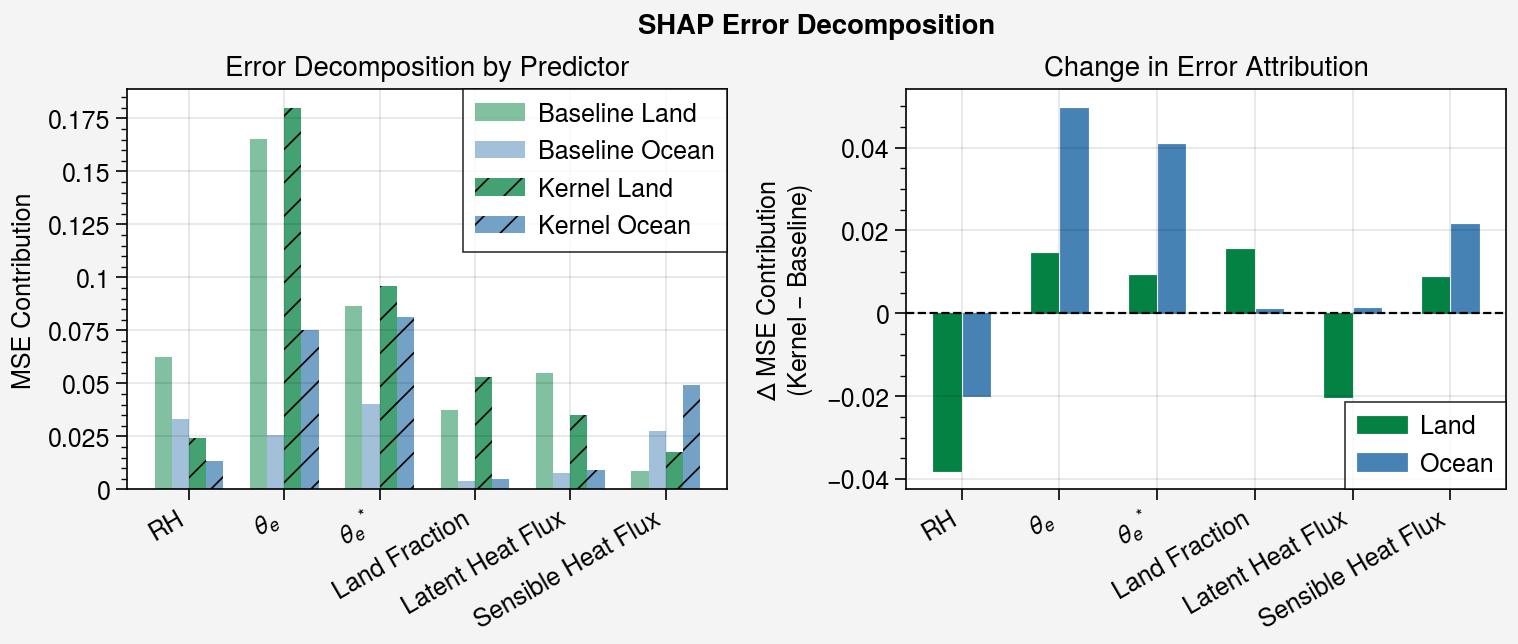

In [69]:
edbl,edbo,edkl,edko,varnames = compute_shap_error(SPLIT)
plot_shap_error(edbl,edbo,edkl,edko,varnames)